<a href="https://colab.research.google.com/github/Justyasir123/data_visualisation_matplotlib/blob/main/matseaborn_datascientist_task5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df=pd.read_csv('DataScientist.csv')

In [ ]:
df

,Unnamed: 0,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Easy Apply
0,0,0,Senior Data Scientist,$111K-$181K (Glassdoor est.),"ABOUT HOPPER\n\nAt Hopper, we’re on a mission ...",3.5,Hopper\n3.5,"New York, NY","Montreal, Canada",501 to 1000 employees,2007,Company - Private,Travel Agencies,Travel & Tourism,Unknown / Non-Applicable,-1,-1
1,1,1,"Data Scientist, Product Analytics",$111K-$181K (Glassdoor est.),"At Noom, we use scientifically proven methods ...",4.5,Noom US\n4.5,"New York, NY","New York, NY",1001 to 5000 employees,2008,Company - Private,"Health, Beauty, & Fitness",Consumer Services,Unknown / Non-Applicable,-1,-1
2,2,2,Data Science Manager,$111K-$181K (Glassdoor est.),Decode_M\n\nhttps://www.decode-m.com/\n\nData ...,-1.0,Decode_M,"New York, NY","New York, NY",1 to 50 employees,-1,Unknown,-1,-1,Unknown / Non-Applicable,-1,TRUE
3,3,3,Data Analyst,$111K-$181K (Glassdoor est.),Sapphire Digital seeks a dynamic and driven mi...,3.4,Sapphire Digital\n3.4,"Lyndhurst, NJ","Lyndhurst, NJ",201 to 500 employees,2019,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,"Zocdoc, Healthgrades",-1
4,4,4,"Director, Data Science",$111K-$181K (Glassdoor est.),"Director, Data Science - (200537)\nDescription...",3.4,United Entertainment Group\n3.4,"New York, NY","New York, NY",51 to 200 employees,2007,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"BBDO, Grey Group, Droga5",-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3904,3904,4375,AWS Data Engineer,$55K-$112K (Glassdoor est.),About Us\n\nTachyon Technologies is a Digital ...,4.4,Tachyon Technologies\n4.4,"Dublin, OH","Irving, TX",201 to 500 employees,2011,Company - Private,IT Services,Information Technology,$10 to $25 million (USD),-1,-1
3905,3905,4376,Data Analyst â Junior,$55K-$112K (Glassdoor est.),"Job description\nInterpret data, analyze resul...",5.0,"Staffigo Technical Services, LLC\n5.0","Columbus, OH","Woodridge, IL",51 to 200 employees,2008,Company - Private,IT Services,Information Technology,$50 to $100 million (USD),-1,-1
3906,3906,4377,Security Analytics Data Engineer,$55K-$112K (Glassdoor est.),Job DescriptionThe Security Analytics Data Eng...,3.8,"PDS Tech, Inc.\n3.8","Dublin, OH","Irving, TX",5001 to 10000 employees,1977,Company - Private,Staffing & Outsourcing,Business Services,$100 to $500 million (USD),-1,-1
3907,3907,4378,Security Analytics Data Engineer,$55K-$112K (Glassdoor est.),The Security Analytics Data Engineer will inte...,4.0,Data Resource Technologies\n4.0,"Dublin, OH","Omaha, NE",1 to 50 employees,-1,Company - Private,Accounting,Accounting & Legal,Less than $1 million (USD),-1,-1


**DATA CLEANING**

In [ ]:
df.replace(['-1'], [np.nan], inplace=True)
df.replace(['-1.0'], [np.nan], inplace=True)
df.replace([-1], [np.nan], inplace=True)

In [ ]:
df.isnull().sum()


Unnamed: 0              0
index                   0
Job Title               0
Salary Estimate         0
Job Description         0
Rating                409
Company Name            0
Location                0
Headquarters          240
Size                  229
Founded               977
Type of ownership     229
Industry              546
Sector                546
Revenue               229
Competitors          2760
Easy Apply           3745
dtype: int64

Editing the values of column- SALARY

In [ ]:
df_salary = df['Salary Estimate'].str.split("-",expand=True,)

minimum_salary = df_salary[0]
minimum_salary = minimum_salary.str.replace('K',' ')


maximum_salary = df_salary[1].str.replace('(Glassdoor est.)', ' ')
maximum_salary = maximum_salary.str.replace('(', ' ')
maximum_salary = maximum_salary.str.replace(')', ' ')
maximum_salary = maximum_salary.str.replace('K', ' ')
maximum_salary = maximum_salary.str.replace('Employer est.', ' ')
maximum_salary = maximum_salary.str.replace('Per Hour', ' ')

maximum_salary = maximum_salary.str.replace('$', ' ').fillna(0).astype(int)
minimum_salary = minimum_salary.str.replace('$', ' ').fillna(0).astype(int)

# **1- ANALYSIS ON TOP 10 JOB TITLES OF A DATA SCIENCE ASPIRANT**

In [ ]:
jobtitle=df['Job Title'].value_counts().head(10)
jobtitle

Job Title
Data Scientist                   274
Data Engineer                    260
Data Analyst                     246
Senior Data Scientist             91
Machine Learning Engineer         47
Senior Data Analyst               47
Big Data Engineer                 41
Business Intelligence Analyst     39
Senior Data Engineer              37
Lead Data Scientist               23
Name: count, dtype: int64

Text(0.5, 1.0, 'ANALYSIS ON TOP 10 JOB TITLES OF A DATA SCIENCE ASPIRANT')

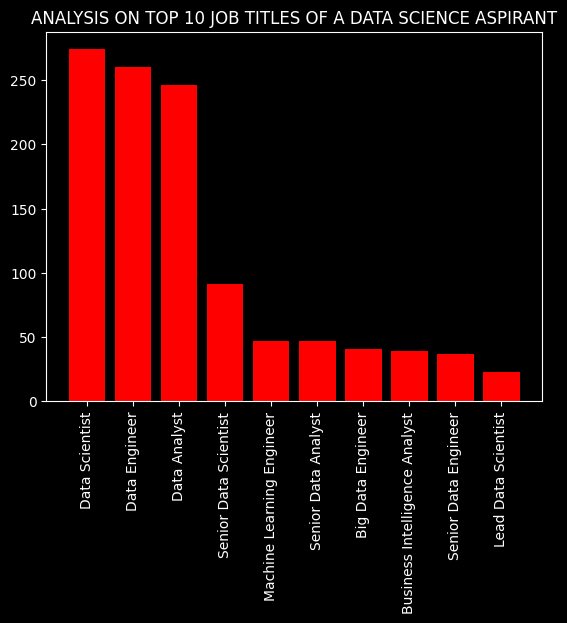

In [ ]:
plt.style.use('dark_background')
plt.bar(jobtitle.index,jobtitle.values,color='red')
plt.xticks(rotation=90)
plt.title('ANALYSIS ON TOP 10 JOB TITLES OF A DATA SCIENCE ASPIRANT')


**INSIGHT:**
it can be seen that aspirants are working in the job title as Data Scientist followed by Data Engineer

# **2- TOP 10 ESTIMATED SALARIES OF A DATA SCIENCE ASPIRANT**

Text(0.5, 1.0, 'TOP 10 ESTIMATED SALARIES OF A DATA SCIENCE ASPIRANT')

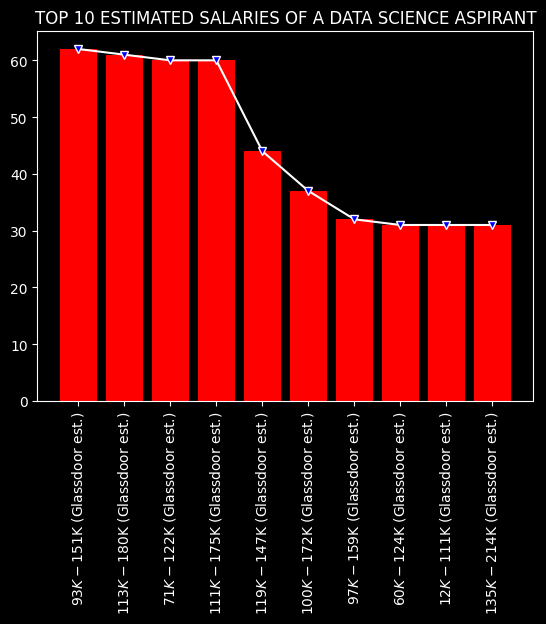

In [ ]:
est_salary=df['Salary Estimate'].value_counts().head(10)
plt.bar(est_salary.index,est_salary.values,color='r')
plt.plot(est_salary.index,est_salary.values,color='white',marker='v',markerfacecolor='blue')
plt.xticks(rotation=90)
plt.title('TOP 10 ESTIMATED SALARIES OF A DATA SCIENCE ASPIRANT')

**INSIGHT:**
It is seen that most number of aspirants are getting an estimated salary of 93k - 151k

# **3- TOP 5 COMPANIES HIRING MOST NUMBER OF DATA SCIENTISTS**

In [ ]:
top5=df['Company Name'].value_counts().head(5)
top5


Company Name
Apple\n4.1                               60
IBM\n3.7                                 57
Amazon\n3.9                              47
Staffigo Technical Services, LLC\n5.0    28
Facebook\n4.5                            25
Name: count, dtype: int64

Text(0.5, 1.0, 'TOP 5 COMPANIES HIRING MOST NUMBER OF DATA SCIENTISTS')

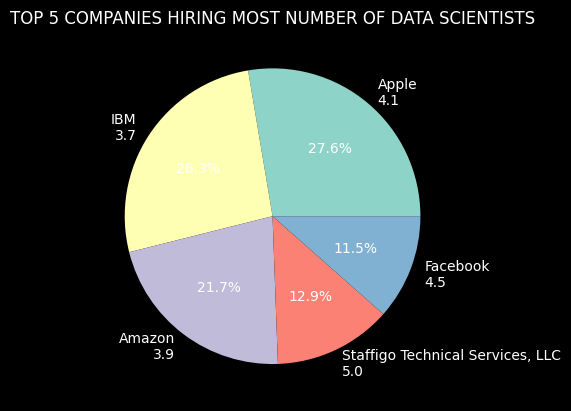

In [ ]:
plt.pie(top5,labels=top5.index,autopct='%1.1f%%')
plt.title('TOP 5 COMPANIES HIRING MOST NUMBER OF DATA SCIENTISTS')


**INSIGHT:**
It is seen that apple is the highest recruter of data scientists after IBM

# **4- TOP WORK LOCATIONS FOR DATA SCIENTISTS**

In [ ]:
workloc=df['Location'].value_counts(10).head(5)
workloc

Location
Austin, TX       0.088258
Chicago, IL      0.084421
San Diego, CA    0.077769
New York, NY     0.077513
Houston, TX      0.056025
Name: proportion, dtype: float64

Text(0.5, 1.0, 'TOP WORK LOCATIONS FOR DATA SCIENTISTS')

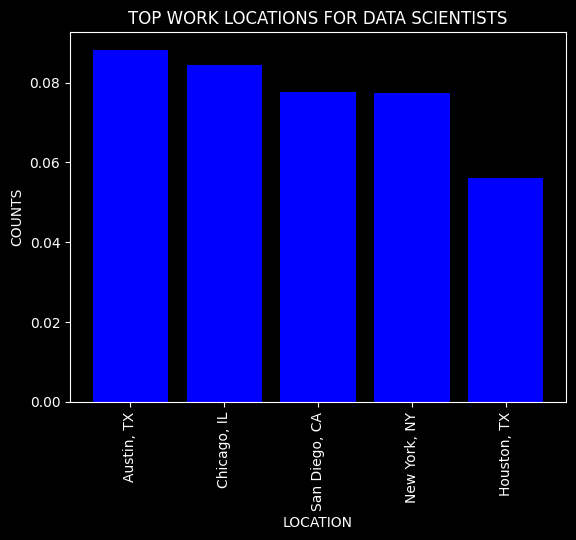

In [ ]:
plt.bar(workloc.index,workloc.values,color='blue')
plt.xticks(rotation=90)
plt.xlabel('LOCATION')
plt.ylabel('COUNTS')
plt.title('TOP WORK LOCATIONS FOR DATA SCIENTISTS')

**INSIGHT:**
Data Scientists are mostly seen in the location Austin, TX

# **5- TOP 10 RATED COMPANIES**

In [ ]:
company_group=df[df['Rating']==5]['Company Name'].value_counts().head(10)
company_group

Company Name
Staffigo Technical Services, LLC\n5.0    28
Georgia IT Inc.\n5.0                      7
Nucleusteq\n5.0                           5
Pro Lancer\n5.0                           4
Vividion Therapeutics\n5.0                3
Kalderos\n5.0                             3
WB Technology\n5.0                        3
Queen Consulting Group, Inc.\n5.0         2
KUNGFU.AI\n5.0                            2
CultureFit Technology Staffing\n5.0       2
Name: count, dtype: int64

Text(0, 0.5, 'COUNTS')

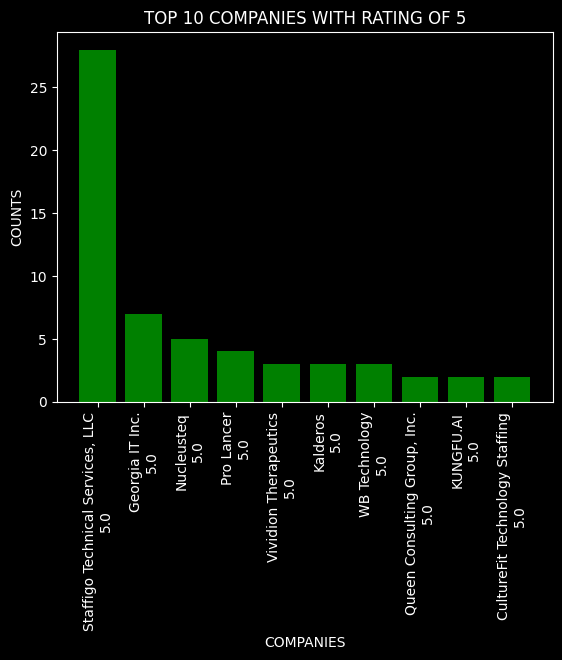

In [ ]:
plt.bar(company_group.index,company_group.values,color='green')
plt.xticks(rotation=90)
plt.title('TOP 10 COMPANIES WITH RATING OF 5')
plt.xlabel('COMPANIES')
plt.ylabel('COUNTS')



**INSIGHT:**
Among the companies with 5 star rating, staffigo Technical Services is providing higher vacancies for data scientist aspirants

In [ ]:
df.columns

Index(['Unnamed: 0', 'index', 'Job Title', 'Salary Estimate',
       'Job Description', 'Rating', 'Company Name', 'Location', 'Headquarters',
       'Size', 'Founded', 'Type of ownership', 'Industry', 'Sector', 'Revenue',
       'Competitors', 'Easy Apply'],
      dtype='object')